In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import h5py
import pandas as pd
import numpy as np
import glob, os

In [5]:
tests_dir = "../TESTS/"

# List available NonMark pickle files
pkl_files = sorted(glob.glob(tests_dir + "dataframe_NonMark_*.pkl"))
for f in pkl_files:
    print(os.path.basename(f))

dataframe_NonMark_Kossak2H_k5_trn4_tst20_2026-Mar-12_at_20-40.pkl
dataframe_NonMark_Kossak_k10_trn4_tst20_2026-Apr-01_at_22-02.pkl
dataframe_NonMark_Kossak_k1_trn4_tst20_2026-Mar-12_at_18-53.pkl
dataframe_NonMark_Kossak_k5_trn4_tst20_2026-Apr-01_at_21-45.h5.pkl
dataframe_NonMark_Kossak_k5_trn4_tst20_2026-Apr-01_at_21-45.pkl
dataframe_NonMark_Kossak_k5_trn4_tst20_2026-Mar-12_at_18-31.pkl
dataframe_NonMark_k5_trn4_tst20_2026-Mar-08_at_14-43.pkl
dataframe_NonMark_sharedH_k5_trn4_tst20_2026-Mar-08_at_16-15.pkl


In [17]:
pkl_file = os.path.basename("dataframe_NonMark_Kossak_k1_trn4_tst20_2026-Apr-01_at_22-29.pkl")

In [18]:
#pl_file = os.path.basename("dataframe_NonMark_Kossak_k5_trn4_tst20_2026-Apr-01_at_21-45.pkl")
#pkl_file = os.path.basename("dataframe_NonMark_Kossak_k10_trn4_tst20_2026-Apr-01_at_22-02.pkl")

print("Using:", pkl_file)
df = pd.read_pickle(tests_dir + pkl_file)

Using: dataframe_NonMark_Kossak_k1_trn4_tst20_2026-Apr-01_at_22-29.pkl


In [7]:
pkl_file = os.path.basename(pkl_files[-1])
print("Using:", pkl_file)
df = pd.read_pickle(tests_dir + pkl_file)

Using: dataframe_NonMark_sharedH_k5_trn4_tst20_2026-Mar-08_at_16-15.pkl


In [19]:
df

,Gamma,State,Time,gt,Fidelity,Infidelity,Distance
0,0.079477,1,0.06000,0.004769,1.000000,3.508305e-14,0.341926
1,0.079477,1,0.08000,0.006358,0.991805,8.194955e-03,0.341926
2,0.079477,1,0.10000,0.007948,0.983446,1.655373e-02,0.341926
3,0.079477,1,0.12000,0.009537,0.975277,2.472308e-02,0.341926
4,0.079477,1,0.14000,0.011127,0.966726,3.327399e-02,0.341926
...,...,...,...,...,...,...,...
751,79.477,20,0.23800,18.915526,0.999702,2.977224e-04,0.340014
752,79.477,20,0.23825,18.935395,0.999701,2.989793e-04,0.340014
753,79.477,20,0.23850,18.955264,0.999700,3.002304e-04,0.340014
754,79.477,20,0.23875,18.975134,0.999699,3.014750e-04,0.340014


In [20]:
# Shorten gamma labels and convert to float for ordered axis
df.replace({'0.079477': '0.079', '0.79477': '0.795', '0.25133': '0.251',
            '2.5133': '2.513', '7.9477': '7.948'}, inplace=True)

df['Gamma']         = df['Gamma'].astype(float)
df['Infidelity']    = df['Infidelity'].abs()
df['Log_Infidelity'] = np.log10(df['Infidelity'])
df.loc[df['Log_Infidelity'] < -12, 'Log_Infidelity'] = -12

pd.unique(df['Gamma'])

/home/zah/anaconda3/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


array([7.9000e-02, 2.5100e-01, 7.9500e-01, 2.5130e+00, 2.5133e+01,
       2.5133e+02, 7.9480e+00, 7.9477e+01])

In [21]:
def log_infidelity_violin(df, title="Non-Markovian model", save_path=None):
    fig, ax = plt.subplots(1, 1, figsize=(6, 6))

    sns.violinplot(ax=ax, data=df, x="Gamma", y="Log_Infidelity",
                   cut=0, scale="width", palette="cool",
                   linewidth=0.5, inner=None, bw="silverman")

    ymin, ymax = -6, -0.1
    tick_range = np.arange(ymin, ymax)
    ax.yaxis.set_ticks(tick_range,
        [r'$10^{-6}$', r'$10^{-5}$', r'$10^{-4}$',
         r'$10^{-3}$', r'$10^{-2}$', r'$10^{-1}$'])
    ax.yaxis.set_ticks(
        [np.log10(x) for p in tick_range for x in np.linspace(10**p, 10**(p+1), 10)],
        minor=True)

    ax.set_ylim(ymin, ymax)
    ax.set_title(title)
    ax.set_xlabel(r'Coupling $\gamma$')
    ax.set_ylabel(r'Infidelity $(1-F)$')

    for level, label in [(0.01, '0.01'), (0.02, '0.02')]:
        ax.hlines(np.log10(level), -0.5, 7.5, colors='black',
                  linestyles='--', alpha=0.8)
        ax.text(7.6, np.log10(level), label, ha='left', va='center')

    if save_path:
        fig.savefig(save_path, bbox_inches='tight')
        print("Saved:", save_path)

    return fig

/tmp/ipykernel_286586/2737449919.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(ax=ax, data=df, x="Gamma", y="Log_Infidelity",
/tmp/ipykernel_286586/2737449919.py:4: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(ax=ax, data=df, x="Gamma", y="Log_Infidelity",
/tmp/ipykernel_286586/2737449919.py:4: FutureWarning: 

The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method='silverman'`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.

  sns.violinplot(ax=ax, data=df, x="Gamma", y="Log_Infidelity",


Saved: LogInfidelity_NonMark_10.pdf


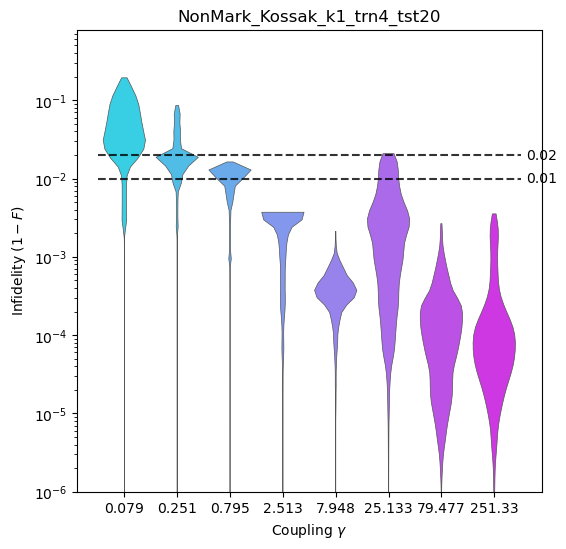

In [22]:
# Extract model label from filename (e.g. "NonMark_k5" or "NonMark_sharedH_k5")
model_label = pkl_file.replace("dataframe_", "").replace(".pkl", "")
model_label = model_label.rsplit("_", 3)[0]   # strip date suffix

fig = log_infidelity_violin(df, title=model_label,
                             save_path="LogInfidelity_NonMark_10.pdf")

/tmp/ipykernel_280091/2737449919.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(ax=ax, data=df, x="Gamma", y="Log_Infidelity",
/tmp/ipykernel_280091/2737449919.py:4: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(ax=ax, data=df, x="Gamma", y="Log_Infidelity",
/tmp/ipykernel_280091/2737449919.py:4: FutureWarning: 

The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method='silverman'`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.

  sns.violinplot(ax=ax, data=df, x="Gamma", y="Log_Infidelity",


Saved: LogInfidelity_NonMark.pdf


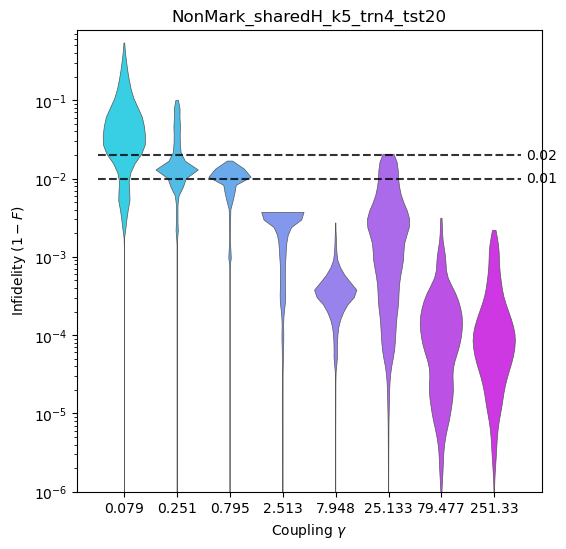

In [11]:
# Extract model label from filename (e.g. "NonMark_k5" or "NonMark_sharedH_k5")
model_label = pkl_file.replace("dataframe_", "").replace(".pkl", "")
model_label = model_label.rsplit("_", 3)[0]   # strip date suffix

fig = log_infidelity_violin(df, title=model_label,
                             save_path="LogInfidelity_NonMark.pdf")

In [ ]:
plt.show()